In [7]:
# ================================
# 1. 匯入套件
# ================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold


from xgboost import XGBClassifier


import matplotlib.pyplot as plt


In [8]:
# 讀取資料
df_train = pd.read_csv("./cs-training.csv")
df_test = pd.read_csv("./cs-test.csv")

X shape: (146076, 16)
y shape: (146076,)
X_kaggle shape: (101503, 16)

========== Fold 1 ==========
Fold 1 AUC: 0.87001

========== Fold 2 ==========
Fold 2 AUC: 0.85633

========== Fold 3 ==========
Fold 3 AUC: 0.86738

========== Fold 4 ==========
Fold 4 AUC: 0.86121

========== Fold 5 ==========
Fold 5 AUC: 0.86895

各 Fold AUC: [0.8700145990786706, 0.856331269277742, 0.8673815888919372, 0.8612052753970773, 0.8689519826264003]
平均 Fold AUC: 0.8647769430543655
OOF AUC: 0.8646637764984824


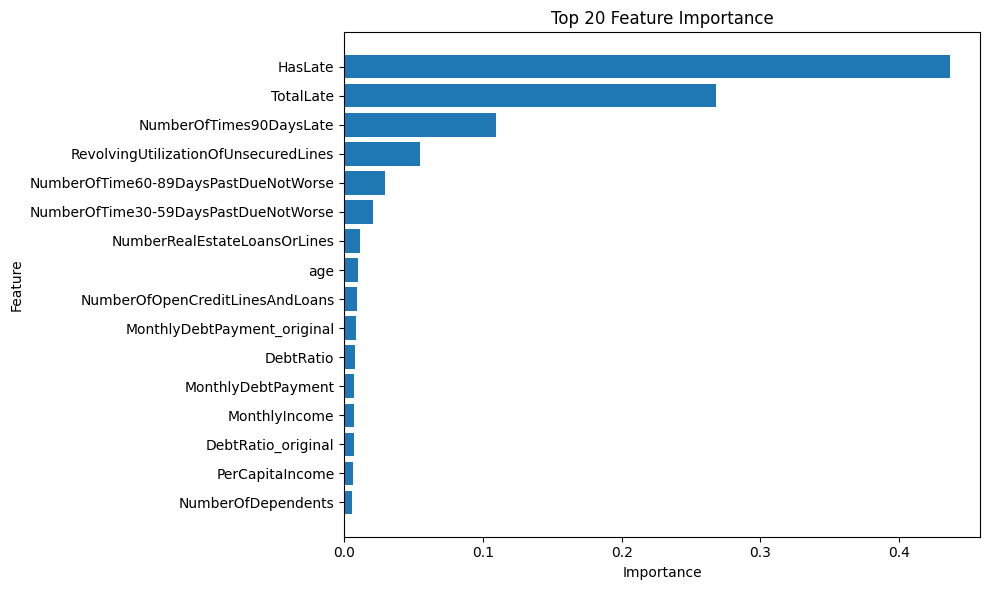

,Id,Probability
0,1,0.059949
1,2,0.042239
2,3,0.017625
3,4,0.074151
4,5,0.100521


In [9]:
# ==============================
# 2. 保留測試集 Id
# ==============================
test_id = df_test["Unnamed: 0"]


# ==============================
# 3. 資料清理
# ==============================

# 移除訓練集中 NumberOfDependents 為空值的資料列
df_train = df_train.dropna(subset=["NumberOfDependents"])

# 保險：移除 y 為空的列
df_train = df_train.dropna(subset=["SeriousDlqin2yrs"])


# ==============================
# 4. 特徵工程
# ==============================

REVOLVING_UPPER = 3
DEBT_RATIO_UPPER = 50

def add_features(df):
    df = df.copy()

    # 1. RevolvingUtilizationOfUnsecuredLines 極端值切片
    df["RevolvingUtilizationOfUnsecuredLines"] = (
        df["RevolvingUtilizationOfUnsecuredLines"].clip(upper=REVOLVING_UPPER)
    )

    # 2. DebtRatio 極端值切片
    # 保留原始 DebtRatio，讓模型同時看到原始值與切片後的值
    df["DebtRatio_original"] = df["DebtRatio"]
    df["DebtRatio"] = df["DebtRatio"].clip(upper=DEBT_RATIO_UPPER)

    # 3. 逾期相關特徵
    late_cols = [
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate"
    ]

    # TotalLate：總逾期次數
    df["TotalLate"] = df[late_cols].sum(axis=1)

    # HasLate：是否曾經逾期
    df["HasLate"] = (df["TotalLate"] > 0).astype(int)

    # 4. 收入與負債相關特徵
    # MonthlyDebtPayment：使用切片後 DebtRatio 估算每月負債壓力
    df["MonthlyDebtPayment"] = df["DebtRatio"] * df["MonthlyIncome"]

    # MonthlyDebtPayment_original：使用原始 DebtRatio 估算每月負債壓力
    df["MonthlyDebtPayment_original"] = df["DebtRatio_original"] * df["MonthlyIncome"]

    # PerCapitaIncome：人均月收入
    df["PerCapitaIncome"] = df["MonthlyIncome"] / (df["NumberOfDependents"] + 1)

    return df


df_train = add_features(df_train)
df_test = add_features(df_test)


# ==============================
# 5. 建立 X / y
# ==============================

X = df_train.drop(columns=["Unnamed: 0", "SeriousDlqin2yrs"])
y = df_train["SeriousDlqin2yrs"]

X_kaggle = df_test.drop(columns=["Unnamed: 0", "SeriousDlqin2yrs"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_kaggle shape:", X_kaggle.shape)


# ==============================
# 6. 5-Fold 交叉驗證與模型訓練（固定 seed=100）
# ==============================

X_arr = X.values
y_arr = y.values
X_kaggle_arr = X_kaggle.values

# 固定本次最佳 random seed，方便後續實驗維持同一個基準
SEED = 100
N_SPLITS = 5

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

oof_preds = np.zeros(len(X_arr))
test_preds = np.zeros(len(X_kaggle_arr))
fold_auc_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_arr, y_arr)):
    print(f"\n========== Fold {fold + 1} ==========")

    X_train_fold = X_arr[train_idx]
    X_valid_fold = X_arr[valid_idx]

    y_train_fold = y_arr[train_idx]
    y_valid_fold = y_arr[valid_idx]

    # 每一折內部獨立補值，避免 Data Leakage
    imputer = SimpleImputer(strategy="median")

    X_train_fold = imputer.fit_transform(X_train_fold)
    X_valid_fold = imputer.transform(X_valid_fold)
    X_kaggle_fold = imputer.transform(X_kaggle_arr)

    xgb = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",

        n_estimators=800,
        learning_rate=0.03,

        max_depth=4,
        min_child_weight=5,

        subsample=0.8,
        colsample_bytree=0.8,

        gamma=0.1,

        reg_alpha=0.1,
        reg_lambda=1.0,

        random_state=SEED + fold,
        n_jobs=-1
    )

    xgb.fit(X_train_fold, y_train_fold)

    valid_pred = xgb.predict_proba(X_valid_fold)[:, 1]
    oof_preds[valid_idx] = valid_pred

    fold_auc = roc_auc_score(y_valid_fold, valid_pred)
    fold_auc_scores.append(fold_auc)

    print(f"Fold {fold + 1} AUC: {fold_auc:.5f}")

    # Kaggle 測試集預測：5 個模型平均
    test_preds += xgb.predict_proba(X_kaggle_fold)[:, 1] / skf.n_splits


print("\n" + "=" * 50)
print("各 Fold AUC:", fold_auc_scores)
print("平均 Fold AUC:", np.mean(fold_auc_scores))
print("OOF AUC:", roc_auc_score(y_arr, oof_preds))
print("=" * 50)


# ==============================
# 7. 使用完整訓練資料訓練 final model，繪製 Feature Importance
# ==============================

final_imputer = SimpleImputer(strategy="median")
X_full = final_imputer.fit_transform(X_arr)

xgb_final = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",

    n_estimators=800,
    learning_rate=0.03,

    max_depth=4,
    min_child_weight=5,

    subsample=0.8,
    colsample_bytree=0.8,

    gamma=0.1,

    reg_alpha=0.1,
    reg_lambda=1.0,

    random_state=SEED,
    n_jobs=-1
)

xgb_final.fit(X_full, y_arr)

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_final.feature_importances_
}).sort_values(by="importance", ascending=False)

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importance")
plt.tight_layout()
plt.savefig("images/feature_importance_seed_100.png", dpi=300, bbox_inches="tight")
plt.show()

feature_importance.head(20)


# ==============================
# 8. 建立 Submission
# ==============================

submission = pd.DataFrame({
    "Id": test_id,
    "Probability": test_preds
})

submission.to_csv("submission_seed_100.csv", index=False)

submission.head()
